In [1]:
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams.update(
    {
        "text.usetex": True,
        "axes.labelsize": 20,
        "legend.fontsize": 13,
        "xtick.labelsize": 15,
        "ytick.labelsize": 15,
    }
)

In [2]:
# ---------------------------
# Parameter values
# ---------------------------
v_QCD = 0.1  # GeV
M_W = 80.379
G_mu = 1.1663787e-5
M_h = 125.1
pi = np.pi

def getParams(g, mZp):
    params = {}

    
    # Derived parameters
    g2_at_mZ = np.sqrt(8 * M_W**2 * G_mu / np.sqrt(2))
    lam_h = (g2_at_mZ**2) / (16 * M_W**2) * 2 * (M_h**2)
    vh_at_mZ = np.sqrt(4 * M_W**2 / g2_at_mZ**2)
    
    params["lam_p"] = 2 * lam_h * (vh_at_mZ * 2 * g / mZp) ** 2
    params["lam_phi"] = g**4 / pi**2
    params["mu"] = mZp
    params["vev"] = mZp / (2 * g)
    
    params["omega_star"] = mZp
    params["f_star"] = mZp
    return params


# ---------------------------
# Potential function V(phi)
# ---------------------------
def V(phi, params):
    return (
        -params["lam_p"] * v_QCD**2 / 2.0 * phi**2
        + 0.25 * params["lam_phi"] * phi**4
        + (3.0 / (64.0 * pi**2))
        * (2 * g * phi) ** 4
        * (np.log((2 * g * phi / params["mu"]) ** 2) - 5.0 / 6.0)
    )


def V_num(phi_tilde, params):
    return 1 / (params["omega_star"] * params["f_star"]) ** 2 * (V(phi_tilde * params["f_star"], params))

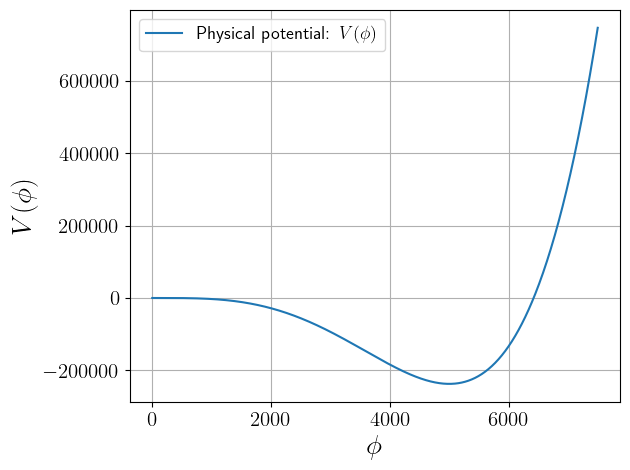

In [3]:
# ---------------------------
# Plotting physical potential
# ---------------------------
g = 0.01
mZp = 1e2
params = getParams(g, mZp)
phis = np.linspace(0.1, params["vev"] * 1.5, 800)
plt.figure()
plt.plot(phis, V(phis, params), label="Physical potential: " + r"$V(\phi)$")
plt.xlabel(r"$\phi$")
plt.ylabel(r"$V(\phi)$")
plt.grid(True)
plt.tight_layout()
plt.legend(loc="upper left")
plt.show()

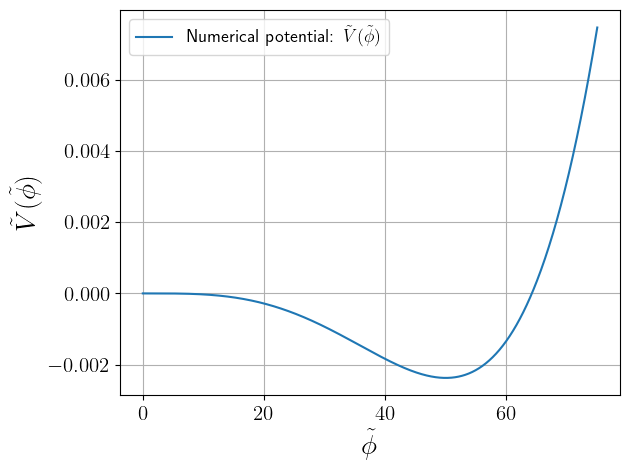

In [4]:
# ---------------------------
# Plotting numerical potential
# ---------------------------
tilde_phis = phis / params["f_star"]
plt.figure()
plt.plot(
    tilde_phis,
    V_num(tilde_phis, params),
    label="Numerical potential: " + r"$\tilde V(\tilde\phi)$",
)
plt.xlabel(r"$\tilde\phi$")
plt.ylabel(r"$\tilde V(\tilde\phi)$")
plt.grid(True)
plt.tight_layout()
plt.legend(loc="upper left")
plt.show()